# 03 — Modeling
ARIMA / XGBoost / LSTM 세 모델을 카테고리별로 학습하고,  
SMAPE 기준으로 예측 성능을 비교합니다.

---
**노트북 실행 순서**
1. `01_EDA.ipynb`
2. `02_feature_engineering.ipynb`
3. `03_modeling.ipynb` ← 현재

## 1. 라이브러리 불러오기

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# 통계 모델
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# ML 모델
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler

# 딥러닝
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 재현성 고정
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("XGBoost version:", xgb.__version__)

TensorFlow version: 2.21.0
XGBoost version: 3.2.0


## 2. 이전 단계 데이터 로드

> feature_engineering.ipynb 와 이어서 실행하는 경우 이 셀은 건너뛰어도 됩니다.  
> 독립 실행 시 반드시 실행하세요.

In [5]:
# ── 공통 설정 ──────────────────────────────────────
PATH            = "../data/"
ANALYSIS_START  = '2017-01-01'
ANALYSIS_END    = '2018-08-31'
TRAIN_END       = '2018-06-30'
TEST_START      = '2018-07-01'
TOP_N           = 10
WINDOW_SIZE     = 14
FEATURE_COLS    = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14',
    'weekday', 'is_weekend', 'month', 'day_of_year'
]

# ── 원본 데이터 재생성 ──────────────────────────────
orders      = pd.read_csv(PATH + "olist_orders_dataset.csv")
order_items = pd.read_csv(PATH + "olist_order_items_dataset.csv")
products    = pd.read_csv(PATH + "olist_products_dataset.csv")

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_date'] = orders['order_purchase_timestamp'].dt.normalize()
orders = orders[
    (orders['order_date'] >= ANALYSIS_START) &
    (orders['order_date'] <= ANALYSIS_END)
]

merged = pd.merge(
    orders[['order_id','order_date']],
    order_items[['order_id','product_id','freight_value']],
    on='order_id', how='inner'
)
merged = pd.merge(
    merged,
    products[['product_id','product_category_name']],
    on='product_id', how='left'
).dropna(subset=['product_category_name'])

demand_df = (
    merged
    .groupby(['order_date','product_category_name'])
    .size()
    .reset_index(name='demand')
)

TOP_CATEGORY_LIST = (
    demand_df.groupby('product_category_name')['demand'].sum()
    .sort_values(ascending=False).head(TOP_N).index.tolist()
)

full_date_range = pd.date_range(start=ANALYSIS_START, end=ANALYSIS_END, freq='D')
filled_frames = []
for cat in TOP_CATEGORY_LIST:
    cat_df = (
        demand_df[demand_df['product_category_name'] == cat]
        .set_index('order_date')[['demand']]
        .reindex(full_date_range, fill_value=0)
    )
    cat_df.index.name = 'order_date'
    cat_df['product_category_name'] = cat
    filled_frames.append(cat_df.reset_index())
demand_filled = pd.concat(filled_frames, ignore_index=True)

# ── Feature Engineering ─────────────────────────────
def add_features(df):
    df = df.copy().sort_values('order_date').reset_index(drop=True)
    df['lag_1']           = df['demand'].shift(1)
    df['lag_7']           = df['demand'].shift(7)
    df['lag_14']          = df['demand'].shift(14)
    df['rolling_mean_7']  = df['demand'].shift(1).rolling(7,  min_periods=1).mean()
    df['rolling_std_7']   = df['demand'].shift(1).rolling(7,  min_periods=2).std().fillna(0)
    df['rolling_mean_14'] = df['demand'].shift(1).rolling(14, min_periods=1).mean()
    df['weekday']         = df['order_date'].dt.weekday
    df['is_weekend']      = (df['weekday'] >= 5).astype(int)
    df['month']           = df['order_date'].dt.month
    df['day_of_year']     = df['order_date'].dt.dayofyear
    return df

fe_frames = []
for cat in TOP_CATEGORY_LIST:
    fe_frames.append(add_features(
        demand_filled[demand_filled['product_category_name'] == cat].copy()
    ))
fe_df_clean = pd.concat(fe_frames, ignore_index=True).dropna(subset=['lag_14'])

# ── Train / Test split ──────────────────────────────
train_raw = demand_filled[demand_filled['order_date'] <= TRAIN_END].copy()
test_raw  = demand_filled[demand_filled['order_date'] >= TEST_START].copy()
train_fe  = fe_df_clean[fe_df_clean['order_date'] <= TRAIN_END].copy()
test_fe   = fe_df_clean[fe_df_clean['order_date'] >= TEST_START].copy()
X_train   = train_fe[FEATURE_COLS]
y_train   = train_fe['demand']
X_test    = test_fe[FEATURE_COLS]
y_test    = test_fe['demand']

# ── LSTM 시퀀스 생성 ────────────────────────────────
def make_sequences(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X).reshape(-1, window, 1), np.array(y)

lstm_data = {}
for cat in TOP_CATEGORY_LIST:
    cat_tr = train_raw[train_raw['product_category_name'] == cat]['demand'].values.astype(float)
    cat_te = test_raw[test_raw['product_category_name']   == cat]['demand'].values.astype(float)
    scaler = MinMaxScaler(feature_range=(0, 1))
    tr_sc  = scaler.fit_transform(cat_tr.reshape(-1,1)).flatten()
    te_sc  = scaler.transform(cat_te.reshape(-1,1)).flatten()
    combined = np.concatenate([tr_sc[-WINDOW_SIZE:], te_sc])
    X_tr, y_tr = make_sequences(tr_sc, WINDOW_SIZE)
    X_te, y_te = make_sequences(combined, WINDOW_SIZE)
    lstm_data[cat] = {'X_train':X_tr,'y_train':y_tr,'X_test':X_te,'y_test':y_te,'scaler':scaler}

print("데이터 로드 완료")
print(f"카테고리 {len(TOP_CATEGORY_LIST)}개:", TOP_CATEGORY_LIST)

데이터 로드 완료
카테고리 10개: ['cama_mesa_banho', 'beleza_saude', 'esporte_lazer', 'moveis_decoracao', 'informatica_acessorios', 'utilidades_domesticas', 'relogios_presentes', 'telefonia', 'ferramentas_jardim', 'automotivo']


## 3. 평가 지표 — SMAPE

SMAPE(Symmetric Mean Absolute Percentage Error)를 사용합니다.  
수요가 0인 날이 있어 일반 MAPE는 분모가 0이 되는 문제가 있으므로 SMAPE가 더 안정적입니다.

$$\text{SMAPE} = \frac{100}{n} \sum_{t=1}^{n} \frac{|y_t - \hat{y}_t|}{(|y_t| + |\hat{y}_t|) / 2}$$

In [6]:
def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Symmetric Mean Absolute Percentage Error.
    분모가 0인 경우(실제·예측 모두 0) 해당 샘플은 0으로 처리합니다.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    error = np.where(
        mask,
        np.abs(y_true - y_pred) / denominator * 100,
        0.0
    )
    return float(np.mean(error))


# 결과 저장용 딕셔너리
results = {}   # {category: {'arima': {...}, 'xgb': {...}, 'lstm': {...}}}

print("SMAPE 함수 및 결과 저장 구조 초기화 완료")

SMAPE 함수 및 결과 저장 구조 초기화 완료


---
## 4. ARIMA

### 설계 원칙
- 카테고리별로 독립 모델을 학습합니다
- ADF 검정으로 정상성(stationarity)을 확인 후 d(차분 차수)를 결정합니다
- order(p, d, q)는 기본값 (1, d, 1)에서 시작합니다 — auto_arima를 쓰면 더 정확하지만 시간이 오래 걸립니다
- 1-step ahead rolling forecast 방식: 매일 실제값을 업데이트하며 예측합니다

In [7]:
def get_arima_order(series: np.ndarray) -> tuple:
    """
    ADF 검정으로 정상성을 확인하고 d를 결정합니다.
    p=1, q=1을 고정으로 사용합니다.
    """
    adf_result = adfuller(series, autolag='AIC')
    p_value = adf_result[1]
    d = 0 if p_value < 0.05 else 1   # p < 0.05: 정상 시계열
    return (1, d, 1)


def arima_rolling_forecast(train: np.ndarray, test: np.ndarray, order: tuple) -> np.ndarray:
    """
    Rolling (walk-forward) forecast.
    매 스텝마다 실제값을 history에 추가해 재학습 없이 예측합니다.

    Args:
        train  : 학습 데이터 (1D array)
        test   : 테스트 데이터 (1D array) — 예측 타겟
        order  : ARIMA (p, d, q)

    Returns:
        predictions : 예측값 (1D array, 음수는 0으로 클리핑)
    """
    history = list(train)
    predictions = []

    for t in range(len(test)):
        try:
            model  = ARIMA(history, order=order)
            fitted = model.fit()
            yhat   = fitted.forecast(steps=1)[0]
        except Exception:
            yhat = history[-1]  # 학습 실패 시 직전값으로 대체

        predictions.append(max(0.0, yhat))  # 음수 예측값 방지
        history.append(test[t])             # 실제값으로 history 업데이트

    return np.array(predictions)


print("ARIMA 학습 시작 — 카테고리별 rolling forecast")
print("(카테고리당 약 1~3분 소요될 수 있습니다)")
print()

for cat in TOP_CATEGORY_LIST:
    train_series = train_raw[train_raw['product_category_name'] == cat]['demand'].values.astype(float)
    test_series  = test_raw[test_raw['product_category_name']   == cat]['demand'].values.astype(float)

    order = get_arima_order(train_series)
    preds = arima_rolling_forecast(train_series, test_series, order)
    score = smape(test_series, preds)

    if cat not in results:
        results[cat] = {}
    results[cat]['arima'] = {
        'pred'  : preds,
        'actual': test_series,
        'smape' : score,
        'order' : order,
    }

    print(f"  {cat[:35]:<35}  order={order}  SMAPE={score:.2f}%")

print("\nARIMA 완료")

ARIMA 학습 시작 — 카테고리별 rolling forecast
(카테고리당 약 1~3분 소요될 수 있습니다)

  cama_mesa_banho                      order=(1, 0, 1)  SMAPE=39.30%
  beleza_saude                         order=(1, 1, 1)  SMAPE=38.93%
  esporte_lazer                        order=(1, 1, 1)  SMAPE=40.69%
  moveis_decoracao                     order=(1, 0, 1)  SMAPE=50.55%
  informatica_acessorios               order=(1, 1, 1)  SMAPE=45.71%
  utilidades_domesticas                order=(1, 1, 1)  SMAPE=44.94%
  relogios_presentes                   order=(1, 1, 1)  SMAPE=41.19%
  telefonia                            order=(1, 0, 1)  SMAPE=56.05%
  ferramentas_jardim                   order=(1, 0, 1)  SMAPE=68.74%
  automotivo                           order=(1, 0, 1)  SMAPE=46.58%

ARIMA 완료


---
## 5. XGBoost

### 설계 원칙
- 전체 카테고리를 하나의 모델로 학습합니다 (카테고리 간 패턴 공유)
- `product_category_name`을 레이블 인코딩해서 feature로 추가합니다
- 예측 시에는 카테고리별로 분리해서 SMAPE를 계산합니다

In [8]:
from sklearn.preprocessing import LabelEncoder

# 카테고리 레이블 인코딩
le = LabelEncoder()
le.fit(TOP_CATEGORY_LIST)

train_fe_xgb = train_fe.copy()
test_fe_xgb  = test_fe.copy()
train_fe_xgb['cat_encoded'] = le.transform(train_fe_xgb['product_category_name'])
test_fe_xgb['cat_encoded']  = le.transform(test_fe_xgb['product_category_name'])

XGB_FEATURE_COLS = FEATURE_COLS + ['cat_encoded']

X_tr_xgb = train_fe_xgb[XGB_FEATURE_COLS]
y_tr_xgb = train_fe_xgb['demand']
X_te_xgb = test_fe_xgb[XGB_FEATURE_COLS]
y_te_xgb = test_fe_xgb['demand']

# ── 모델 학습 ────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0,
)

xgb_model.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_te_xgb, y_te_xgb)],
    verbose=False
)

# ── 카테고리별 예측 및 SMAPE ─────────────────────────
print("XGBoost 예측 결과")
print()

xgb_preds_all = np.maximum(0, xgb_model.predict(X_te_xgb))  # 음수 방지
test_fe_xgb['xgb_pred'] = xgb_preds_all

for cat in TOP_CATEGORY_LIST:
    cat_test = test_fe_xgb[test_fe_xgb['product_category_name'] == cat]
    actual   = cat_test['demand'].values
    preds    = cat_test['xgb_pred'].values
    score    = smape(actual, preds)

    if cat not in results:
        results[cat] = {}
    results[cat]['xgb'] = {
        'pred'  : preds,
        'actual': actual,
        'smape' : score,
    }

    print(f"  {cat[:35]:<35}  SMAPE={score:.2f}%")

print("\nXGBoost 완료")

XGBoost 예측 결과

  cama_mesa_banho                      SMAPE=42.08%
  beleza_saude                         SMAPE=38.95%
  esporte_lazer                        SMAPE=39.96%
  moveis_decoracao                     SMAPE=53.93%
  informatica_acessorios               SMAPE=44.16%
  utilidades_domesticas                SMAPE=46.97%
  relogios_presentes                   SMAPE=43.17%
  telefonia                            SMAPE=55.39%
  ferramentas_jardim                   SMAPE=68.01%
  automotivo                           SMAPE=45.85%

XGBoost 완료


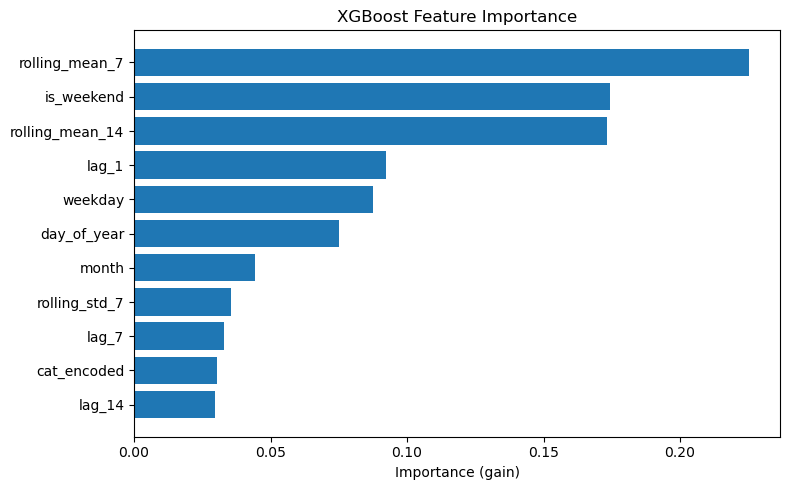

In [9]:
# Feature Importance 시각화
fi = pd.Series(
    xgb_model.feature_importances_,
    index=XGB_FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi.index, fi.values)
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

---
## 6. LSTM

### 설계 원칙
- 카테고리별로 독립 모델을 학습합니다 (수요 스케일이 달라 공유 모델이 불리)
- `MinMaxScaler`로 정규화, 예측 후 역변환합니다
- EarlyStopping으로 과적합을 방지합니다
- 구조: LSTM(64) → Dropout → LSTM(32) → Dense(1)

In [10]:
def build_lstm_model(window: int) -> Sequential:
    """
    2-layer LSTM 모델을 생성합니다.

    Args:
        window : 입력 시퀀스 길이 (timesteps)

    Returns:
        컴파일된 Keras Sequential 모델
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

print("LSTM 학습 시작 — 카테고리별 독립 모델")
print("(카테고리당 약 30초~2분 소요)")
print()

for cat in TOP_CATEGORY_LIST:
    d = lstm_data[cat]

    model = build_lstm_model(WINDOW_SIZE)

    model.fit(
        d['X_train'], d['y_train'],
        epochs          = 100,
        batch_size      = 16,
        validation_split= 0.1,
        callbacks       = [early_stopping],
        verbose         = 0
    )

    # 예측 (스케일 역변환)
    pred_scaled = model.predict(d['X_test'], verbose=0).flatten()
    pred_orig   = d['scaler'].inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    pred_orig   = np.maximum(0, pred_orig)  # 음수 방지

    actual_scaled = d['y_test']
    actual_orig   = d['scaler'].inverse_transform(actual_scaled.reshape(-1,1)).flatten()

    score = smape(actual_orig, pred_orig)

    if cat not in results:
        results[cat] = {}
    results[cat]['lstm'] = {
        'pred'  : pred_orig,
        'actual': actual_orig,
        'smape' : score,
    }

    print(f"  {cat[:35]:<35}  SMAPE={score:.2f}%")

print("\nLSTM 완료")

LSTM 학습 시작 — 카테고리별 독립 모델
(카테고리당 약 30초~2분 소요)

  cama_mesa_banho                      SMAPE=42.93%
  beleza_saude                         SMAPE=43.34%
  esporte_lazer                        SMAPE=45.12%
  moveis_decoracao                     SMAPE=56.48%
  informatica_acessorios               SMAPE=46.47%
  utilidades_domesticas                SMAPE=50.74%
  relogios_presentes                   SMAPE=47.25%
  telefonia                            SMAPE=56.89%
  ferramentas_jardim                   SMAPE=67.89%
  automotivo                           SMAPE=51.46%

LSTM 완료


---
## 7. 모델 성능 비교표

In [11]:
# ── SMAPE 비교 테이블 ────────────────────────────────
rows = []
for cat in TOP_CATEGORY_LIST:
    row = {'category': cat}
    for model_name in ['arima', 'xgb', 'lstm']:
        row[f'smape_{model_name}'] = results[cat][model_name]['smape']
    row['best_model'] = min(
        ['arima', 'xgb', 'lstm'],
        key=lambda m: results[cat][m]['smape']
    )
    rows.append(row)

smape_df = pd.DataFrame(rows)
smape_df['smape_mean'] = smape_df[['smape_arima','smape_xgb','smape_lstm']].mean(axis=1)

print("=" * 70)
print("SMAPE 비교 (낮을수록 좋음)")
print("=" * 70)
print(smape_df[['category','smape_arima','smape_xgb','smape_lstm','best_model']]
      .to_string(index=False))
print()
print("── 카테고리 평균 SMAPE ──")
for m in ['arima','xgb','lstm']:
    print(f"  {m.upper():<8}: {smape_df[f'smape_{m}'].mean():.2f}%")
print()
print("── 모델별 최적 카테고리 수 ──")
print(smape_df['best_model'].value_counts().to_string())

SMAPE 비교 (낮을수록 좋음)
              category  smape_arima  smape_xgb  smape_lstm best_model
       cama_mesa_banho    39.301899  42.084998   42.934215      arima
          beleza_saude    38.927346  38.951022   43.344847      arima
         esporte_lazer    40.686845  39.955585   45.121148        xgb
      moveis_decoracao    50.545871  53.926473   56.480959      arima
informatica_acessorios    45.711041  44.162069   46.470931        xgb
 utilidades_domesticas    44.937031  46.973843   50.736939      arima
    relogios_presentes    41.191257  43.172063   47.247806      arima
             telefonia    56.047741  55.391679   56.892318        xgb
    ferramentas_jardim    68.736411  68.009774   67.888135       lstm
            automotivo    46.577407  45.845157   51.461610        xgb

── 카테고리 평균 SMAPE ──
  ARIMA   : 47.27%
  XGB     : 47.85%
  LSTM    : 50.86%

── 모델별 최적 카테고리 수 ──
best_model
arima    5
xgb      4
lstm     1


---
## 8. 예측 결과 시각화

카테고리별로 실제값 vs 세 모델 예측값을 비교합니다.

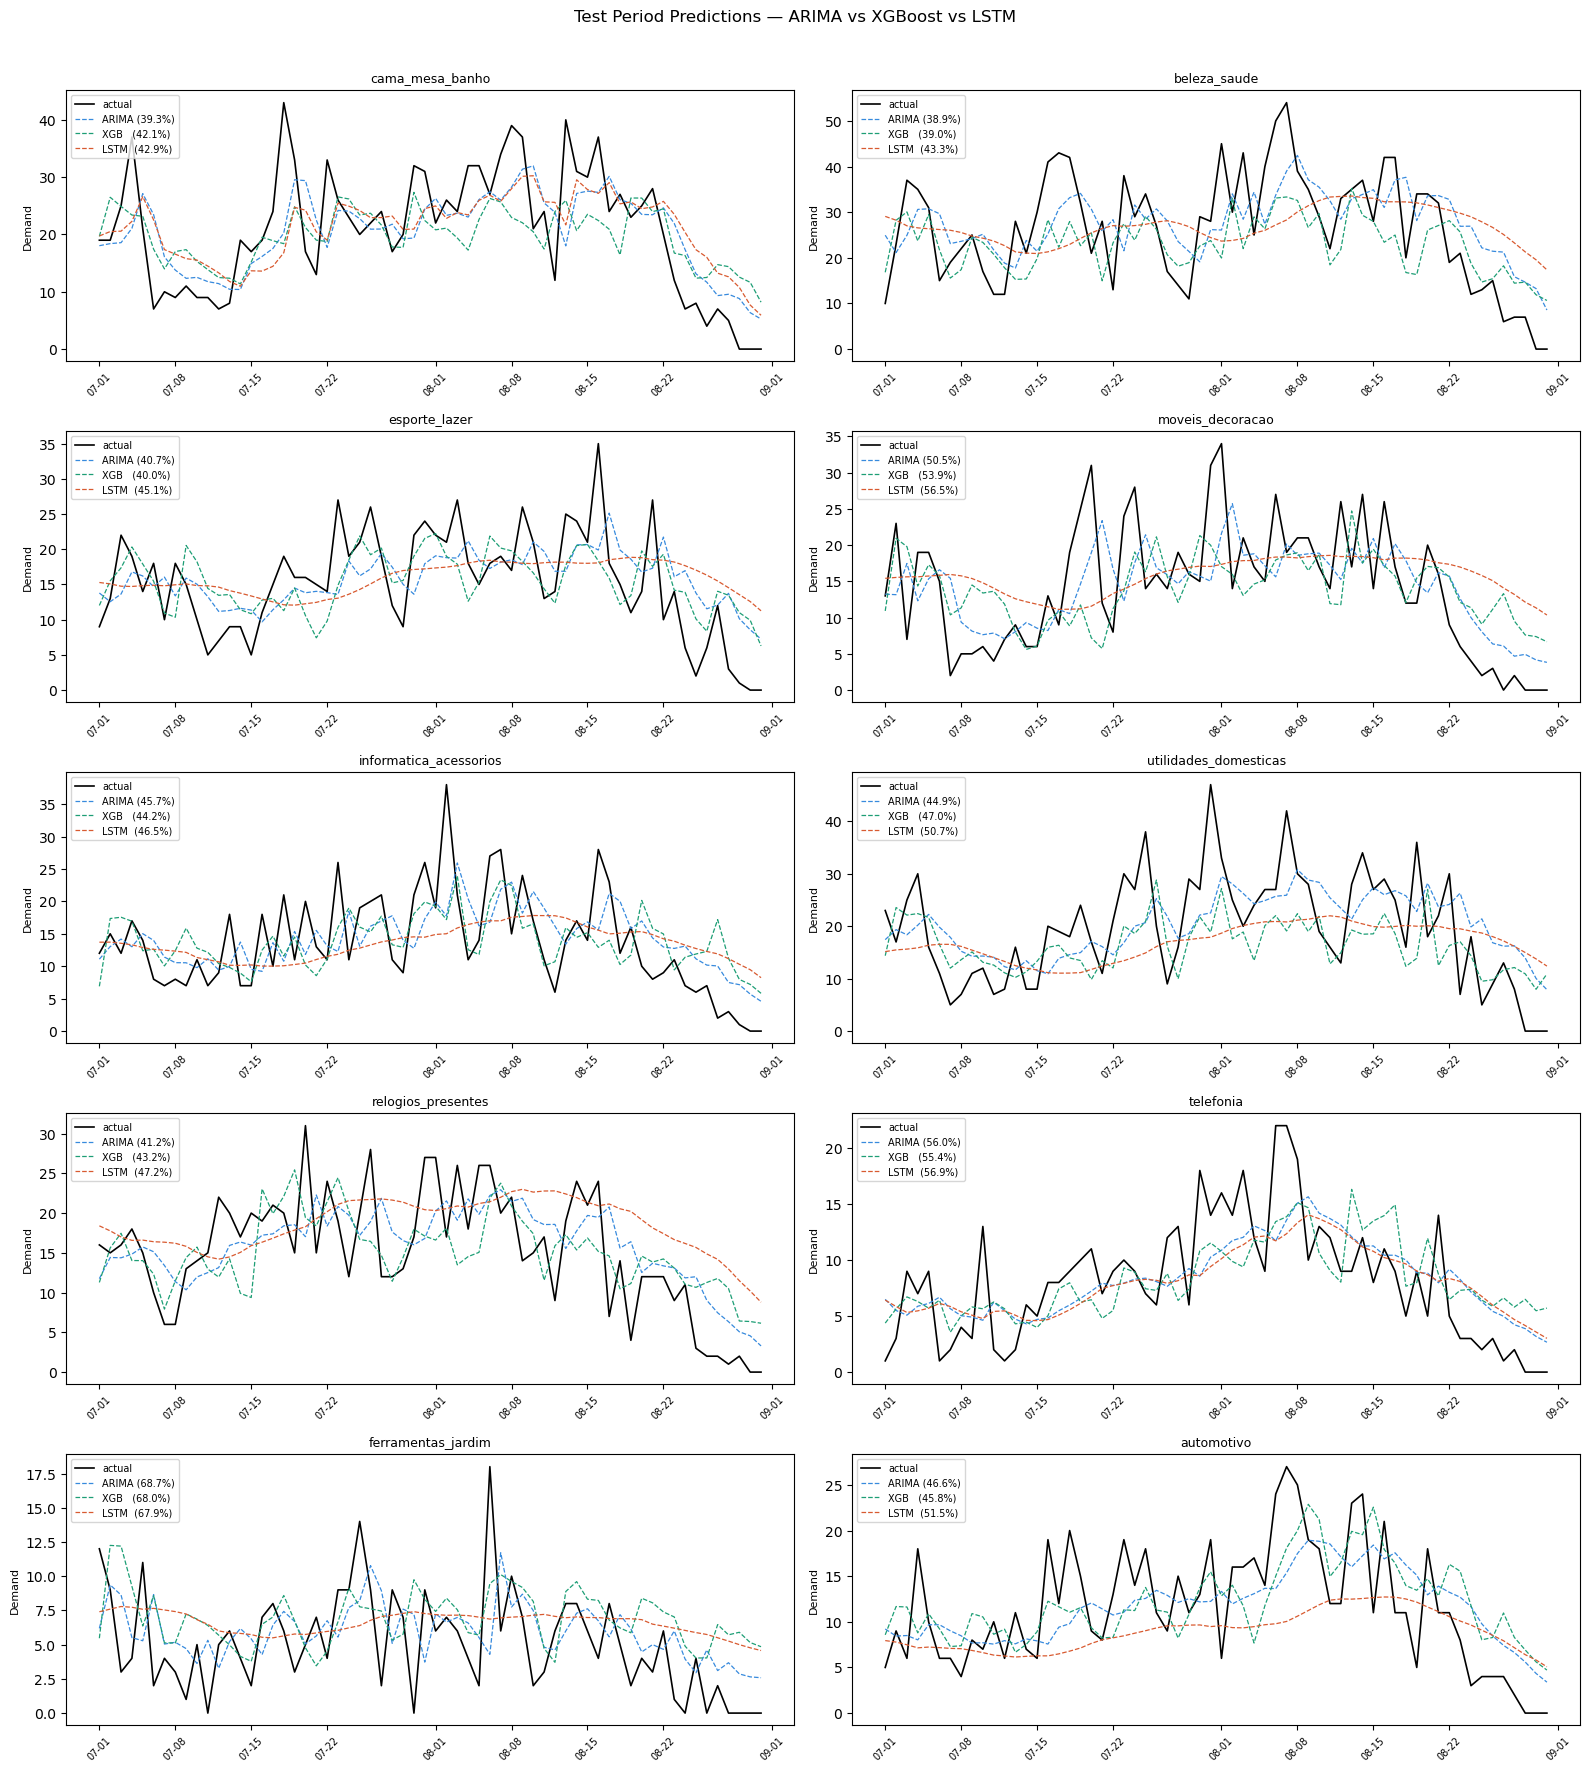

In [12]:
test_dates = pd.date_range(start=TEST_START, end=ANALYSIS_END, freq='D')

n_cols = 2
n_rows = (TOP_N + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, cat in enumerate(TOP_CATEGORY_LIST):
    ax   = axes[i]
    r    = results[cat]

    # 날짜 길이 맞추기 (LSTM은 window만큼 짧을 수 있음)
    arima_dates = test_dates[:len(r['arima']['actual'])]
    xgb_dates   = test_dates[:len(r['xgb']['actual'])]
    lstm_dates  = test_dates[:len(r['lstm']['actual'])]

    ax.plot(arima_dates, r['arima']['actual'], color='black',   linewidth=1.2, label='actual')
    ax.plot(arima_dates, r['arima']['pred'],   color='#378ADD', linewidth=0.9, linestyle='--', label=f"ARIMA ({r['arima']['smape']:.1f}%)")
    ax.plot(xgb_dates,   r['xgb']['pred'],     color='#1D9E75', linewidth=0.9, linestyle='--', label=f"XGB   ({r['xgb']['smape']:.1f}%)")
    ax.plot(lstm_dates,  r['lstm']['pred'],    color='#D85A30', linewidth=0.9, linestyle='--', label=f"LSTM  ({r['lstm']['smape']:.1f}%)")

    ax.set_title(cat, fontsize=9)
    ax.set_ylabel('Demand', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.legend(fontsize=7, loc='upper left')

for j in range(len(TOP_CATEGORY_LIST), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Test Period Predictions — ARIMA vs XGBoost vs LSTM", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

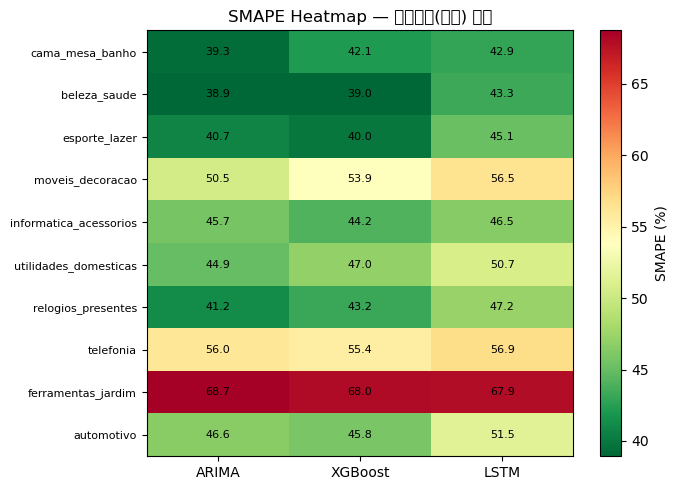

In [13]:
# ── SMAPE 히트맵 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

heat_data = smape_df.set_index('category')[['smape_arima','smape_xgb','smape_lstm']]
heat_data.columns = ['ARIMA','XGBoost','LSTM']

im = ax.imshow(heat_data.values, aspect='auto', cmap='RdYlGn_r')
plt.colorbar(im, ax=ax, label='SMAPE (%)')

ax.set_xticks(range(3))
ax.set_xticklabels(['ARIMA','XGBoost','LSTM'])
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=8)

for r_idx in range(len(heat_data)):
    for c_idx in range(3):
        val = heat_data.values[r_idx, c_idx]
        ax.text(c_idx, r_idx, f'{val:.1f}', ha='center', va='center', fontsize=8)

ax.set_title("SMAPE Heatmap — 낮을수록(초록) 좋음")
plt.tight_layout()
plt.show()

---
## 9. 결과 저장

비용 시뮬레이션 노트북(`04_cost_simulation.ipynb`)에서 사용할  
예측값과 실제값을 CSV로 저장합니다.

In [14]:
save_rows = []

for cat in TOP_CATEGORY_LIST:
    r = results[cat]
    n_arima = len(r['arima']['actual'])
    n_lstm  = len(r['lstm']['actual'])   # window 때문에 arima보다 짧을 수 있음

    for t in range(n_arima):
        row = {
            'date'    : test_dates[t],
            'category': cat,
            'actual'  : r['arima']['actual'][t],
            'pred_arima': r['arima']['pred'][t],
            'pred_xgb'  : r['xgb']['pred'][t]   if t < len(r['xgb']['pred'])  else np.nan,
            'pred_lstm' : r['lstm']['pred'][t - (n_arima - n_lstm)] if t >= (n_arima - n_lstm) else np.nan,
        }
        save_rows.append(row)

pred_df = pd.DataFrame(save_rows)
pred_df.to_csv('../data/predictions.csv', index=False)

# SMAPE 요약도 저장
smape_df.to_csv('../data/smape_summary.csv', index=False)

print("저장 완료")
print(f"  predictions.csv : {pred_df.shape}")
print(f"  smape_summary.csv: {smape_df.shape}")
print()
print("predictions.csv 샘플:")
pred_df.head(10)

저장 완료
  predictions.csv : (620, 6)
  smape_summary.csv: (10, 6)

predictions.csv 샘플:


,date,category,actual,pred_arima,pred_xgb,pred_lstm
0,2018-07-01,cama_mesa_banho,19.0,18.041348,19.670481,19.738840
1,2018-07-02,cama_mesa_banho,19.0,18.401553,26.488190,20.504585
2,2018-07-03,cama_mesa_banho,25.0,18.567984,24.896883,20.575371
3,2018-07-04,cama_mesa_banho,37.0,21.066309,23.392931,22.284986
4,2018-07-05,cama_mesa_banho,21.0,27.129580,23.172873,26.601763
5,2018-07-06,cama_mesa_banho,7.0,23.467981,17.435163,22.546295
6,2018-07-07,cama_mesa_banho,10.0,16.083678,13.988255,17.358835
7,2018-07-08,cama_mesa_banho,9.0,13.788668,17.020773,16.567867
8,2018-07-09,cama_mesa_banho,11.0,12.344226,17.353289,15.779478
9,2018-07-10,cama_mesa_banho,9.0,12.516557,15.288475,15.536925


---
## 10. 최종 요약

다음 단계: `04_cost_simulation.ipynb`

In [15]:
print("=" * 55)
print("모델링 완료 — 비용 시뮬레이션 진입 전 체크")
print("=" * 55)
print()
print("[ SMAPE 전체 평균 ]")
for m in ['arima','xgb','lstm']:
    avg = smape_df[f'smape_{m}'].mean()
    print(f"  {m.upper():<8}: {avg:.2f}%")
print()
print("[ 모델별 최적 카테고리 수 ]")
print(smape_df['best_model'].value_counts().to_string())
print()
print("[ 저장된 파일 ]")
print("  ../data/predictions.csv   — 예측값 + 실제값")
print("  ../data/smape_summary.csv — 카테고리별 SMAPE")
print()
print("핵심 질문: '예측 정확도(SMAPE)가 높은 모델이 비용도 낮은가?'")
print("→ 04_cost_simulation.ipynb 에서 확인합니다")

모델링 완료 — 비용 시뮬레이션 진입 전 체크

[ SMAPE 전체 평균 ]
  ARIMA   : 47.27%
  XGB     : 47.85%
  LSTM    : 50.86%

[ 모델별 최적 카테고리 수 ]
best_model
arima    5
xgb      4
lstm     1

[ 저장된 파일 ]
  ../data/predictions.csv   — 예측값 + 실제값
  ../data/smape_summary.csv — 카테고리별 SMAPE

핵심 질문: '예측 정확도(SMAPE)가 높은 모델이 비용도 낮은가?'
→ 04_cost_simulation.ipynb 에서 확인합니다
